# Laboratorio 2: Clasificadores Binarios


# Scikit-learn buscará el conjunto de datos MNIST

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

## Extraer datos y etiquetas

In [3]:
X, y = mnist.data, mnist.target
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


# Se divide el conjunto de datos
## Se usaran 60.000 elementos para entrenamiento
## Se usaran 10.000 elementos para prueba

In [4]:
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

# Escalar datos
## Como las imagenes de MNIST estan formadas por píxeles cuyos valores van de 0 a 255 (donde 0 es blanco y 255 es negro), podemos divir todo entre 255 y los valores quedarán entre 0 y 1, funcionaría igual y sería más optimo

In [5]:
X_train = X_train / 255.0
X_test = X_test / 255.0

# Entrenamiento de clasificadores binarios


## Convertimos el problema a binario: Es '5' o no es '5'

In [6]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

## Definimos los 4 clasificadores (incluyendo KNeighbors como se pide)

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve

clasificadores = {
    "KNeighbors": KNeighborsClassifier(),
    "SGD Classifier": SGDClassifier(random_state=42),
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

resultados_roc = {}

for nombre, clf in clasificadores.items():
    print(f"--- Evaluando: {nombre} ---")
    clf.fit(X_train, y_train_5)
    y_pred = clf.predict(X_test)

    if hasattr(clf, "predict_proba"):
        y_scores = clf.predict_proba(X_test)[:, 1]
    else:
        y_scores = clf.decision_function(X_test)

    print(f"Precisión: {precision_score(y_test_5, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test_5, y_pred):.4f}")
    print(f"F1: {f1_score(y_test_5, y_pred):.4f}")
    print(f"AUC: {roc_auc_score(y_test_5, y_scores):.4f}\n")

    fpr, tpr, umbrales = roc_curve(y_test_5, y_scores)
    resultados_roc[nombre] = (fpr, tpr)

--- Evaluando: KNeighbors ---
Precisión: 0.9738
Recall: 0.9574
F1: 0.9655
AUC: 0.9962

--- Evaluando: SGD Classifier ---
Precisión: 0.9460
Recall: 0.7859
F1: 0.8585
AUC: 0.9735

--- Evaluando: Regresión Logística ---
Precisión: 0.9147
Recall: 0.8296
F1: 0.8701
AUC: 0.9759

--- Evaluando: Random Forest ---
Precisión: 0.9936
Recall: 0.8677
F1: 0.9264
AUC: 0.9992



# Grafica de la Cruva ROC

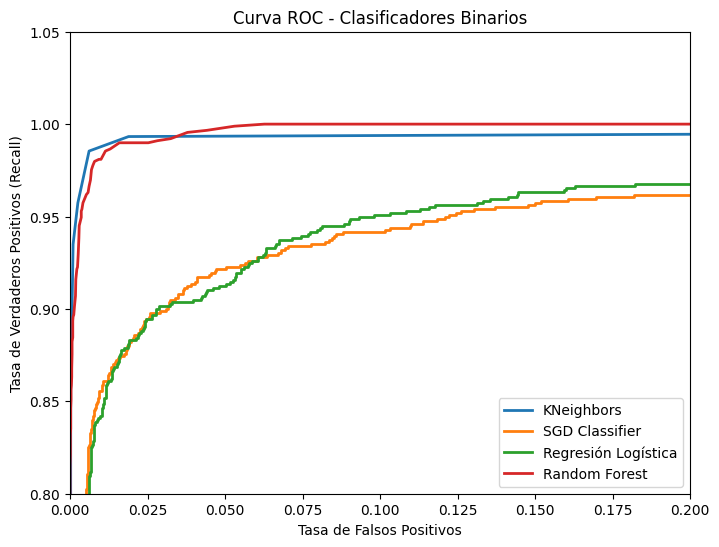

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
for nombre, (fpr, tpr) in resultados_roc.items():
    plt.plot(fpr, tpr, linewidth=2, label=nombre)

plt.axis([0, 0.2, 0.8, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Clasificadores Binarios')
plt.legend(loc="lower right")
plt.show()